In [52]:
import pprint

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#from get_product_config import get_product_config
from pystac_client import Client

from odc.stac import configure_rio, stac_load

In [53]:
product_name = "gm_ls8_ls9_annual"

In [54]:
configure_rio(
    cloud_defaults=True,
    aws={"aws_unsigned": True},
    AWS_S3_ENDPOINT="s3.af-south-1.amazonaws.com",
)

In [55]:
catalog = Client.open("https://explorer.digitalearth.africa/stac")

In [56]:
central_lat = -25.74
central_lon = 27.86

buffer = 0.04

study_area_lat = (central_lat - buffer, central_lat + buffer)
study_area_lon = (central_lon - buffer, central_lon + buffer)

bbox = [study_area_lon[0], study_area_lat[0], study_area_lon[1], study_area_lat[1]]

start_date = "2021"
end_date = "2021"

resolution=30

collections = [product_name]

In [57]:
query = catalog.search(
    bbox=bbox, collections=collections, datetime=f"{start_date}/{end_date}"
)

In [58]:
items = list(query.get_items())
print(f"Found: {len(items):d} datasets")

Found: 2 datasets


/usr/local/lib/python3.10/dist-packages/pystac_client/item_search.py:836: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


In [59]:
measurements = ("green", "swir_1")
crs = "EPSG:6933"
resolution = 30

In [60]:
config = {'gm_ls8_ls9_annual': {'aliases': {'BCDEV': 'BCMAD',
                                   'EDEV': 'EMAD',
                                   'SDEV': 'SMAD',
                                   'band_2': 'SR_B2',
                                   'band_3': 'SR_B3',
                                   'band_4': 'SR_B4',
                                   'band_5': 'SR_B5',
                                   'band_6': 'SR_B6',
                                   'band_7': 'SR_B7',
                                   'bcdev': 'BCMAD',
                                   'bcmad': 'BCMAD',
                                   'blue': 'SR_B2',
                                   'count': 'COUNT',
                                   'edev': 'EMAD',
                                   'emad': 'EMAD',
                                   'green': 'SR_B3',
                                   'nir': 'SR_B5',
                                   'red': 'SR_B4',
                                   'sdev': 'SMAD',
                                   'smad': 'SMAD',
                                   'swir_1': 'SR_B6',
                                   'swir_2': 'SR_B7'},
                       'assets': {'BCMAD': {'data_type': 'float32',
                                            'nodata': 'NaN',
                                            'unit': '1'},
                                  'COUNT': {'data_type': 'uint16',
                                            'nodata': 0,
                                            'unit': '1'},
                                  'EMAD': {'data_type': 'float32',
                                           'nodata': 'NaN',
                                           'unit': '1'},
                                  'SMAD': {'data_type': 'float32',
                                           'nodata': 'NaN',
                                           'unit': '1'},
                                  'SR_B2': {'data_type': 'uint16',
                                            'nodata': 0,
                                            'unit': '1'},
                                  'SR_B3': {'data_type': 'uint16',
                                            'nodata': 0,
                                            'unit': '1'},
                                  'SR_B4': {'data_type': 'uint16',
                                            'nodata': 0,
                                            'unit': '1'},
                                  'SR_B5': {'data_type': 'uint16',
                                            'nodata': 0,
                                            'unit': '1'},
                                  'SR_B6': {'data_type': 'uint16',
                                            'nodata': 0,
                                            'unit': '1'},
                                  'SR_B7': {'data_type': 'uint16',
                                            'nodata': 0,
                                            'unit': '1'}}}}

In [61]:
ds_ls = stac_load(
    items,
    bands=measurements,
    crs=crs,
    resolution=resolution,
    chunks={},
    stac_cfg=config,
    bbox=bbox,
).squeeze()

In [62]:
ds_ls


<xarray.Dataset> Size: 324kB
Dimensions:      (y: 308, x: 259)
Coordinates:
  * y            (y) float64 2kB -3.172e+06 -3.172e+06 ... -3.182e+06 -3.182e+06
  * x            (x) float64 2kB 2.684e+06 2.684e+06 ... 2.692e+06 2.692e+06
    spatial_ref  int32 4B 6933
    time         datetime64[ns] 8B 2021-01-01
Data variables:
    green        (y, x) uint16 160kB dask.array<chunksize=(308, 259), meta=np.ndarray>
    swir_1       (y, x) uint16 160kB dask.array<chunksize=(308, 259), meta=np.ndarray>

In [63]:
# Normalize the data by dividing the data by 10,000.
ds_ls = ds_ls / 10000
# Calculate the MNDWI index.
ds_ls["MNDWI"] = (ds_ls.green - ds_ls.swir_1) / (ds_ls.green + ds_ls.swir_1)
# Convert the xarray.Dataset to a DataArray.
mndwi = ds_ls.MNDWI.compute()

In [64]:
water_mndwi = mndwi.where(mndwi > 0.5, np.nan)
water_mndwi = water_mndwi.where(np.isnan(water_mndwi), 1)

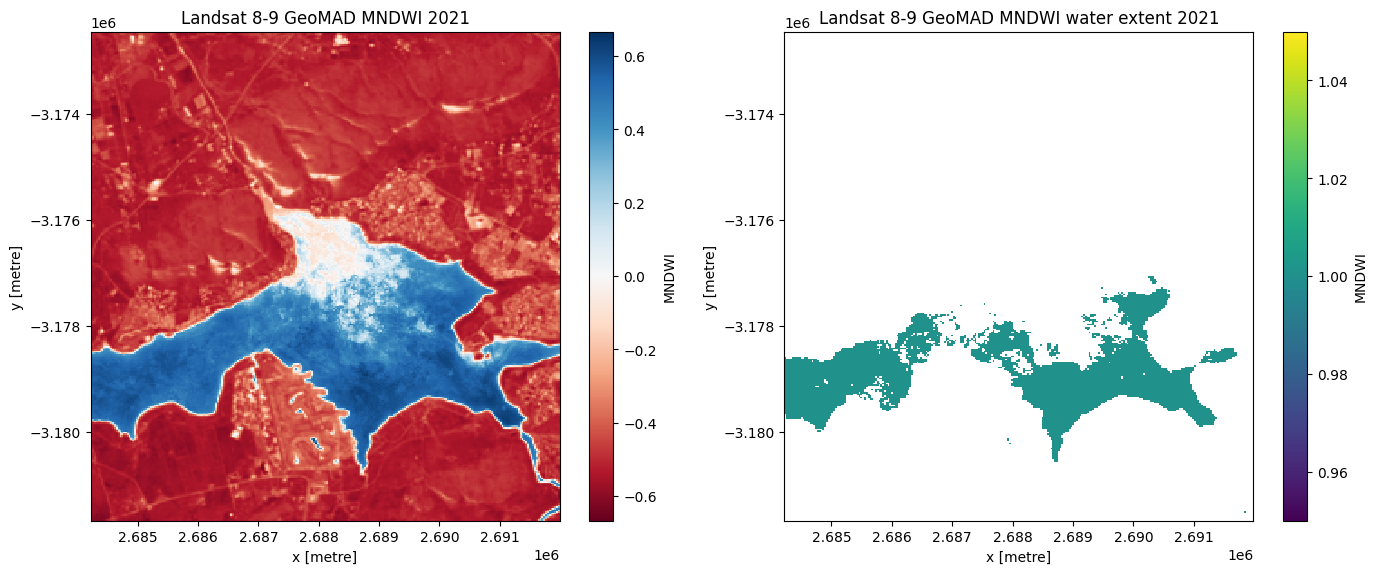

In [65]:
# Plot.
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
mndwi.plot(ax=ax[0], cmap="RdBu")
water_mndwi.plot(ax=ax[1])

ax[0].set_title("Landsat 8-9 GeoMAD MNDWI 2021")
ax[1].set_title("Landsat 8-9 GeoMAD MNDWI water extent 2021")
plt.tight_layout();